# AIC 2026 — OCR toàn bộ keyframe bằng **PP-OCRv6** (Kaggle 2×T4)

Đọc chữ xuất hiện trên màn hình của mọi keyframe, mỗi video ghi một file `<video_id>.json`
cùng schema với `Feature_Dataset/Image_captioning` để backend index chung một chỗ.

## Vì sao PP-OCRv6

Bản mới nhất của PaddleOCR, mạnh hơn v5 ở **cả hai tầng**:

| | Detection Hmean | Recognition Acc | Params |
|---|---:|---:|---:|
| PP-OCRv5_server | 81,6% | 78,1% | — |
| **PP-OCRv6_medium** | **86,2%** | **83,2%** | 34,5M |
| PP-OCRv6_small | 84,1% | 81,3% | 7,7M |
| PP-OCRv6_tiny | 80,6% | 73,5% | 1,5M |

Đây là OCR **không phải VLM**: detection + recognition tách rời, chạy nhanh và **trả về
confidence cho từng dòng** — thứ VLM không có, và là van chống nhiễu quan trọng nhất khi
extract 177.321 ảnh.

## ⚠️ Hai thứ PHẢI kiểm tra trước khi chạy full

Notebook có sẵn hai cổng kiểm tra ở **mục 4**. Đừng bỏ qua.

**1. Tiếng Việt có dấu.** Doc của PP-OCRv6 ghi hỗ trợ *"50 ngôn ngữ… và 46 ngôn ngữ hệ Latin"*
nhưng **không nêu tên tiếng Việt**. "Hệ Latin" không đồng nghĩa với "đọc được tiếng Việt":
tiếng Việt có 134 ký tự có dấu (`ế ề ể ễ ệ ắ ằ ẳ ẵ ặ ộ ố ồ ổ ỗ`…). Nếu bộ ký tự của model
không chứa chúng, `Cần Thơ` sẽ ra `Can Tho` hoặc rác. Cell kiểm tra soi thẳng file dictionary
của model **và** chạy thử trên keyframe thật.

**2. Tốc độ trên T4.** Doc ghi `PP-OCRv6_medium` đạt **0,29 s/ảnh trên A100**. T4 chậm hơn
A100 nhiều lần → có thể ~1 s/ảnh, tức ~25 h cho 177k trên 2 GPU, **vượt hạn mức 30h/tuần**.
Con số đó đo trên ảnh tài liệu nhiều chữ, keyframe sẽ nhanh hơn — nhưng **phải đo thật**.
Nếu chậm quá thì đổi `TIER = 'small'` (7,7M, vẫn 81,3% — cao hơn cả v5_server).

## Phần cứng: 2× T4, mỗi cái 16 GB

**VRAM không phải giới hạn ở đây** — `PP-OCRv6_medium` chỉ ~133 MB weight, dùng chưa tới 1%
của 16 GB. Thứ quyết định là **thông lượng**, nên notebook khai thác phần cứng theo ba hướng:

| Hướng | Cách làm | Vì sao |
|---|---|---|
| Batch lớn | `DET_BATCH=16`, `REC_BATCH=128` | Feature map detection ở 1280px mới là phần tốn bộ nhớ (~0,3–0,5 GB/ảnh); 16 ảnh ≈ 6–8 GB, vừa khít 16 GB |
| Dùng thật 2 GPU | Một engine trên mỗi GPU + **kiểm chứng bằng `nvidia-smi`** | Paddle không đảm bảo tôn trọng `device=` — hai replica có thể cùng rơi xuống `gpu:0`, song song thành giả |
| Đọc ảnh song song | `IO_WORKERS=8` cho decode JPEG và dHash | Khi GPU chạy nhanh, giải mã JPEG trên CPU mới là nút cổ chai |

Cell nạp engine **soi VRAM từng GPU** sau khi chạy thử, và smoke test **đo tăng tốc thật** của
2 GPU thay vì giả định ×2. Nếu song song không ăn, notebook chỉ bạn dùng `SHARD_COUNT = 2` với
hai session riêng — cách chắc ăn nhất với Paddle.

## Cài đặt Kaggle (panel bên phải)

- Accelerator → `GPU T4 ×2`
- Internet → `On` (tải paddlepaddle + weight)

Chạy lần lượt từ trên xuống. Session bị cắt thì mở session mới chạy lại — video nào xong sẽ
được bỏ qua (xem `Add Input → Your Work` ở cell cuối).

### Mỗi đợt chạy bao lâu

> **giờ ≈ số_keyframe × ms_mỗi_ảnh ÷ 1000 ÷ số_GPU ÷ 3600**

| ms/ảnh (1 GPU) | mỗi đợt ~88k, 2 GPU | cả dataset, 2 GPU |
|---:|---:|---:|
| 150 ms | ~1,8 h | ~3,7 h |
| 300 ms | ~3,7 h | ~7,4 h |
| 600 ms | ~7,3 h | ~14,8 h |
| 1000 ms | ~12,2 h | ~24,6 h |

Cell smoke test in ra con số thật. **Lấy nó nhân lên trước khi bấm Save & Run All.**

In [1]:
import subprocess, sys

def sh(cmd):
    print('>>', cmd, flush=True)
    return subprocess.run(cmd, shell=True).returncode

def why_fails(module):
    """'' nếu import được, ngược lại trả stderr."""
    out = subprocess.run([sys.executable, '-c', f'import {module}'],
                         capture_output=True, text=True)
    return '' if out.returncode == 0 else (out.stderr or 'loi khong ro')

PIP = f'{sys.executable} -m pip install -q'

# Index của Paddle theo bản CUDA. Kaggle hiện dùng CUDA 12.x -> cu126.
# Nếu run_check() ở cuối cell báo không thấy GPU, đổi sang cu123 hoặc cu118.
PADDLE_CHANNEL = 'https://www.paddlepaddle.org.cn/packages/stable/cu126/'

# ============================================================================
# CÀI ĐẶT — đúng như doc PaddleOCR, hai lệnh
# ============================================================================
# Doc: "python -m pip install paddleocr", rồi "To actually run model inference,
# install your chosen inference engine". Từ 3.5 PaddleOCR tách thư viện khỏi engine,
# nên bước 2 là bắt buộc nếu muốn chạy GPU.
#
# Vì sao có -i: PyPI chỉ có paddlepaddle-gpu 2.6.2 (thời CUDA 11), còn PP-OCRv6 cần
# paddle 3.x -> phải lấy từ index riêng của Paddle.
sh(f'{PIP} -U paddleocr')
sh(f'{PIP} paddlepaddle-gpu -i {PADDLE_CHANNEL}')

# ============================================================================
# TỪ ĐÂY TRỞ XUỐNG CHỈ CHẠY KHI CÓ LỖI — cài trót lọt thì không dòng nào chạy
# ============================================================================
error = why_fails('paddleocr')

if error and ('nccl' in error.lower() or 'libtorch' in error):
    # paddleocr -> paddlex -> modelscope -> import torch. Cài paddle hay HẠ CẤP
    # nvidia-nccl-cu12, làm torch dựng sẵn của Kaggle mất symbol:
    #   ImportError: libtorch_cuda.so: undefined symbol: ncclCommShrink
    # ncclCommShrink là API của NCCL >= 2.27. --no-deps để chỉ thay đúng gói nccl.
    print()
    print('torch bi ha cap nccl -> nang lai:')
    sh(f'{PIP} -U --no-deps "nvidia-nccl-cu12>=2.27"')
    error = why_fails('paddleocr')

if error:
    print()
    print('paddleocr chua import duoc:')
    print(error.strip()[-600:])
    print('Cell nap engine con mot nhanh du phong nua (chan torch), cu chay tiep.')

# ============================================================================
# KIỂM TRA — 5 giây, chặn kiểu hỏng không có thông báo
# ============================================================================
# Wheel CPU cài nhầm vẫn "import paddle" ngon lành, chỉ chạy chậm ~50x trong im lặng.
# Phát hiện sau 6 tiếng chạy thì mất trắng, nên kiểm tra ngay.
sh(f'{sys.executable} -c "import paddle; paddle.utils.run_check()"')
if not error:
    # An toan: subprocess o tren da xac nhan import duoc roi.
    import paddleocr
    print('paddleocr', paddleocr.__version__)
sh('nvidia-smi --query-gpu=name,memory.total --format=csv')

>> /usr/bin/python3 -m pip install -q -U paddleocr
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.8/146.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.0/156.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.2/435.2 kB 25.4 MB/s eta 0:00:0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires PyYAML<6.1,>=6.0.3, but you have pyyaml 6.0.2 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 551.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 48.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 41.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 63.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 11.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-cublas-cu12==12.8.4.1; platform_system == "Linux", but you have nvidia-cublas-cu12 12.6.4.1 which is incompatible.
torch 2.10.0+cu128 requires nvidia-cuda-cupti-cu12==12.8.90; platform_system == "Linux", but you have nvidia-cuda-cupti-cu12 12.6.80 which is incompatible.
torch 2.10.0+cu128 requires nvidia-cuda-nvrtc-cu12==12.8.93; platform_system == "Linux", but you have nvidia-cuda-nvrtc-cu12 12.6.77 which is incompatible.
torch 2.10.0+cu128 requires nvidia-cuda-runtime-cu12==12.8.90; platform_system == "Linux", but you have nvidia-cuda-runtime-cu12 12.6.77 which is incompatible.
torch 2.10.0+cu128 requires nvidia-cudnn-cu12==9.10.2.21; platform_system == "Linux", but you have nvidia-cudnn-cu12 9.5.1.17 which is incompatible.
torch 2.10.0+cu128 requires nvidia-cufft-cu12==11.3.3.


torch bi ha cap nccl -> nang lai:
>> /usr/bin/python3 -m pip install -q -U --no-deps "nvidia-nccl-cu12>=2.27"
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.1/342.1 MB 5.3 MB/s eta 0:00:00
>> /usr/bin/python3 -c "import paddle; paddle.utils.run_check()"


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/paddle/pir/math_op_patch.py:241: UserWarning: Tensor do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(
I0815 11:24:19.302121   170 pir_interpreter.cc:1529] New Executor is Running ...
W0815 11:24:19.304031   170 gpu_resources.cc:116] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 12.8
I0815 11:24:19.305941   170 pir_interpreter.cc:1552] pir interpreter is running by multi-thread mode ...
[2026-08-15 11:24:19,566] [    INFO] cloud_utils.py:135 - get cluster from args:job_server:None pods:['rank:0 id:None addr:127.0.0.1 p

Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 GPU.


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
======================= Modified FLAGS detected =======================
FLAGS(name='FLAGS_curand_dir', current_value='/usr/local/lib/python3.12/dist-packages/paddle/../nvidia/curand/lib', default_value='')
FLAGS(name='FLAGS_selected_gpus', current_value='1', default_value='')
FLAGS(name='FLAGS_enable_pir_in_executor', current_value=True, default_value=

PaddlePaddle works well on 2 GPUs.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
paddleocr 3.7.0
>> nvidia-smi --query-gpu=name,memory.total --format=csv
name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


0

## 1. Cấu hình

### Chia việc thế nào cho hợp lý

Dataset **rất lệch**, nên thứ tự chạy quyết định việc bạn có xong hay không:

| | video | keyframe | % | | | video | keyframe | % |
|---|---:|---:|---:|---|---|---:|---:|---:|
| **L26** (a–e) | 498 | 79.590 | **45%** | | L30 | 96 | 7.915 | 4% |
| **L25** | 88 | 37.445 | **21%** | | L21 | 29 | 7.800 | 4% |
| L29 | 23 | 10.771 | 6% | | L24 | 43 | 6.781 | 4% |
| L28 | 24 | 10.683 | 6% | | L27 | 16 | 4.914 | 3% |
| L22 | 31 | 9.096 | 5% | | L23 | 25 | 2.326 | 1% |

Riêng L26 + L25 đã là **66%** toàn bộ 177.321 keyframe. Cắt đôi kiểu "L21–L25 / L26–L30" sẽ ra
tỉ lệ 1:3 — một session xong sớm, session kia không kịp chạy hết. Vì vậy `TARGET_FOLDERS` chia
sẵn **2 đợt cân theo số keyframe**:

| Đợt | Folder | Keyframe |
|---|---|---:|
| 1 | L26_a…e, L27, L23 | 86.830 (49%) |
| 2 | L25, L21, L22, L24, L28, L29, L30 | 90.491 (51%) |

Kết quả hai đợt **không đè lên nhau** — mỗi video một file JSON riêng.

### Tham số quan trọng nhất cho tiếng Việt: `DET_UNCLIP_RATIO`

Detector trả về box ôm sát chữ, rồi "nới" ra theo tỉ lệ này. Mặc định `1.5` **hay cắt cụt phần
dấu nằm trên và dưới chữ** (`ế`, `ộ`, `ữ`) — recognizer nhận được ảnh mất dấu thì đọc sai, và
bạn sẽ tưởng model không hỗ trợ tiếng Việt trong khi thật ra chỉ là box quá chặt.

Notebook để `1.6`. Nếu mục 4 cho thấy chữ bị mất dấu, **thử nâng lên `1.8` trước khi kết luận
model không đọc được tiếng Việt**.

### Các tham số lọc nhiễu

| Tham số | Mặc định | Ý nghĩa |
|---|---|---|
| `MIN_BOX_HEIGHT_RATIO` | `0.015` | Bỏ box thấp hơn 1,5% chiều cao ảnh (≈11px ở 720p). Chữ li ti đọc gần như luôn sai. |
| `MIN_CONFIDENCE` | `0.60` | Box dưới ngưỡng **vẫn được ghi vào JSON** nhưng không vào trường `ocr`. |
| `DET_BOX_THRESH` | `0.6` | Ngưỡng nhận box của detector. Hạ xuống → bắt chữ mờ nhưng nhiều rác hơn. |

> **Mọi box qua được lọc kích thước đều được lưu kèm `conf` và `bbox`.** Đổi `MIN_CONFIDENCE`
> sau này chỉ cần chạy lại mục 9 (CPU, vài giây) — **không phải chạy lại 177k ảnh trên GPU**.

In [2]:
import os
from pathlib import Path

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ.setdefault('FLAGS_call_stack_level', '1')   # traceback paddle ngắn lại cho dễ đọc

IS_KAGGLE = bool(os.environ.get('KAGGLE_KERNEL_RUN_TYPE')) or Path('/kaggle/input').exists()

if IS_KAGGLE:
    OCR_DIRECTORY = Path('/kaggle/working/OCR_PP-OCRv6')
    SCRATCH_DIRECTORY = Path('/kaggle/working/_scratch')
else:
    from google.colab import drive
    drive.mount('/content/drive')
    OCR_DIRECTORY = Path('/content/drive/MyDrive/AI Challenge/OCR_PP-OCRv6')
    SCRATCH_DIRECTORY = Path('/content')

# === CHỌN ĐỢT CHẠY CHO SESSION NÀY ===
# Bỏ comment ĐÚNG MỘT đợt. Hai đợt chia theo SỐ KEYFRAME chứ không theo tên: L26 chiếm
# 45% và L25 chiếm 21% toàn dataset, nên cắt đôi kiểu "L21-L25 / L26-L30" sẽ lệch 1:3.
#
#   đợt 1: 86.830 keyframe (49%)  -- trọn L26, cộng hai folder nhỏ cho đủ cân
#   đợt 2: 90.491 keyframe (51%)  -- L25 và toàn bộ phần còn lại

TARGET_FOLDERS = ['Keyframes_L26_a', 'Keyframes_L26_b', 'Keyframes_L26_c',
                  'Keyframes_L26_d', 'Keyframes_L26_e',
                  'Keyframes_L27', 'Keyframes_L23']                            # đợt 1

# TARGET_FOLDERS = ['Keyframes_L25', 'Keyframes_L21', 'Keyframes_L22',
#                   'Keyframes_L24', 'Keyframes_L28', 'Keyframes_L29',
#                   'Keyframes_L30']                                           # đợt 2

# None = chạy mọi thư mục Keyframes* tìm thấy (một session làm hết).
# TARGET_FOLDERS = None

# --- Chia việc cho nhiều session chạy song song ---
SHARD_COUNT = 1
SHARD_INDEX = 0

# --- Model ------------------------------------------------------------------
#   'medium' : 34.5M, det 86.2% / rec 83.2%  <- mặc định, chính xác nhất
#   'small'  : 7.7M,  det 84.1% / rec 81.3%  <- dùng khi medium quá chậm trên T4
#   'tiny'   : 1.5M,  det 80.6% / rec 73.5%  <- chỉ khi thật sự bí thời gian
TIER = 'medium'

# --- Tham số detection ------------------------------------------------------
DET_LIMIT_SIDE_LEN = 1280   # keyframe 1280x720 -> giữ nguyên độ phân giải
DET_THRESH = 0.3
DET_BOX_THRESH = 0.6
# NỚI BOX. Mặc định 1.5 hay cắt cụt dấu tiếng Việt (ế, ộ, ữ) nằm trên/dưới thân chữ.
# Nếu mục 4 cho thấy mất dấu, thử 1.8 TRƯỚC KHI kết luận model không đọc được tiếng Việt.
DET_UNCLIP_RATIO = 1.6

# --- Tham số lọc nhiễu ------------------------------------------------------
# Luật DUY NHẤT áp ngay lúc extract; box bị nó loại KHÔNG có trong JSON.
MIN_BOX_HEIGHT_RATIO = 0.015
MIN_BOX_WIDTH_PX = 6

# Box dưới ngưỡng VẪN ĐƯỢC GHI vào JSON (kèm conf) nhưng không vào trường 'ocr'.
# Nhờ vậy đổi ngưỡng sau này chỉ cần chạy mục 9, không phải chạy lại GPU.
MIN_CONFIDENCE = 0.60

# --- Batch (chỉnh cho 2x T4 16 GB) ------------------------------------------
# PP-OCRv6_medium chỉ ~133 MB weight nên VRAM KHÔNG phải giới hạn. Thứ tốn bộ nhớ là
# feature map của detection ở 1280px: ~0,3-0,5 GB/ảnh. DET_BATCH=16 -> ~6-8 GB, vừa
# đẹp trong 16 GB mà vẫn còn chỗ cho recognition. Giảm xuống 8 nếu gặp OOM.
DET_BATCH = 16
# Crop dòng chữ bé (cao ~48px) nên batch lớn gần như miễn phí bộ nhớ, và bản tin
# thường 5-15 dòng/ảnh -> batch 128 gom được nhiều ảnh, GPU không chạy lô tí hon.
REC_BATCH = 128

# Ở tốc độ cao, giải mã JPEG trên CPU mới là nút cổ chai chứ không phải GPU.
# Kaggle cho 4 nhân -> 8 thread đọc ảnh là đủ che độ trễ đĩa.
IO_WORKERS = 8

# Keyframe liên tiếp trong một shot gần giống nhau -> gom bằng dHash, chỉ ảnh đại diện
# tốn GPU. JSON vẫn ghi đủ mọi keyframe.
# Ngưỡng đặt CHẶT: dòng chyron đổi nội dung chỉ làm xê dịch vài pixel; ngưỡng lỏng sẽ
# gộp nhầm hai frame khác chữ và ta mất đúng cái text cần cho Q&A.
#   -1 = tắt dedup | 0 = chỉ gộp ảnh gần như y hệt (mặc định)
DEDUP_MAX_DISTANCE = 0
DEDUP_HASH_SIZE = 16

# 0 = chạy tới khi hết việc. Đặt 10.5 nếu smoke test cho thấy chậm: Save & Run All bị
# timeout ở 12h sẽ bị đánh là failed và /kaggle/working thường KHÔNG được lưu.
# Mốc chỉ kiểm tra GIỮA HAI VIDEO nên không cắt ngang một video đang chạy dở.
MAX_RUN_HOURS = 0

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

assert TIER in ('medium', 'small', 'tiny'), f'TIER không hợp lệ: {TIER}'

# --- Dò dataset -------------------------------------------------------------
def _looks_like_dataset_root(path):
    """Thư mục dataset thật là thư mục chứa các Keyframes*/ hoặc map-keyframes*/."""
    if not path.is_dir():
        return False
    try:
        children = list(path.iterdir())
    except (PermissionError, OSError):
        return False
    return any(p.is_dir() and (p.name.startswith('Keyframes') or p.name.startswith('map-keyframes'))
               for p in children)

def _discover_dataset_root():
    """Tên dataset mount trên Kaggle hay lồng thêm 1-2 cấp -> quét thay vì hardcode."""
    seeds = [Path('/kaggle/input/aic-dataset'),
             Path('/kaggle/input/datasets/fatle542/aic-dataset'),
             Path('/content/drive/MyDrive/AI Challenge/Dataset_Directory')]
    for seed in seeds:
        if _looks_like_dataset_root(seed):
            return seed
    base = Path('/kaggle/input') if IS_KAGGLE else Path('/content/drive/MyDrive')
    if base.is_dir():
        for pattern in ('*', '*/*', '*/*/*'):
            for candidate in sorted(base.glob(pattern)):
                if _looks_like_dataset_root(candidate):
                    return candidate
    return seeds[0]

def _find_map_keyframes(root):
    direct = root / 'map-keyframes-aic25-b1' / 'map-keyframes'
    if direct.is_dir():
        return direct
    for pattern in ('map-keyframes', '*/map-keyframes', 'map-keyframes*/map-keyframes*'):
        for candidate in sorted(root.glob(pattern)):
            if candidate.is_dir():
                return candidate
    return direct

dataset_root = _discover_dataset_root().resolve()
if not dataset_root.is_dir():
    print('KHÔNG thấy dataset. Trong /kaggle/input đang có:')
    for entry in sorted(Path('/kaggle/input').glob('*')):
        print(' ', entry)
        for sub in sorted(entry.glob('*'))[:10]:
            print('    ', sub.name)
assert dataset_root.is_dir(), f'Không thấy dataset root: {dataset_root}'

MAP_KEYFRAMES_DIRECTORY = _find_map_keyframes(dataset_root)

if TARGET_FOLDERS is None:
    KEYFRAME_ROOTS = sorted(p for p in dataset_root.iterdir()
                            if p.is_dir() and p.name.startswith('Keyframes'))
    missing = []
else:
    KEYFRAME_ROOTS, missing = [], []
    for folder in TARGET_FOLDERS:
        selected = (dataset_root / folder.strip()).resolve()
        assert dataset_root in selected.parents, f'Chỉ nhận đường dẫn tương đối: {folder}'
        (KEYFRAME_ROOTS if selected.is_dir() else missing).append(
            selected if selected.is_dir() else folder)

assert KEYFRAME_ROOTS, ('Không thấy thư mục keyframe nào. Trong dataset có: '
                        + ', '.join(sorted(p.name for p in dataset_root.iterdir() if p.is_dir())[:20]))
assert 1 <= SHARD_COUNT and 0 <= SHARD_INDEX < SHARD_COUNT, 'SHARD_INDEX phải nằm trong [0, SHARD_COUNT)'

OUTPUT_ROOT = OCR_DIRECTORY.resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = SCRATCH_DIRECTORY / 'ocr_checkpoint'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if missing:
    print('Bỏ qua thư mục không tồn tại:', ', '.join(str(m) for m in missing))
print('Dataset:', dataset_root)
print('Map    :', MAP_KEYFRAMES_DIRECTORY, '' if MAP_KEYFRAMES_DIRECTORY.is_dir() else '(KHÔNG THẤY)')
print('Output :', OUTPUT_ROOT)
print('Model  :', f'PP-OCRv6_{TIER}_det + PP-OCRv6_{TIER}_rec')
print(f'Sẽ OCR {len(KEYFRAME_ROOTS)} thư mục keyframe'
      + (f' | shard {SHARD_INDEX + 1}/{SHARD_COUNT}' if SHARD_COUNT > 1 else ''))

Dataset: /kaggle/input/datasets/fatle542/aic-dataset
Map    : /kaggle/input/datasets/fatle542/aic-dataset/map-keyframes-aic25-b1/map-keyframes 
Output : /kaggle/working/OCR_PP-OCRv6
Model  : PP-OCRv6_medium_det + PP-OCRv6_medium_rec
Sẽ OCR 7 thư mục keyframe


## 2. Liệt kê keyframe + nối về timeline video

`map-keyframes/<video_id>.csv` cho `frame_idx` thật của mỗi keyframe. Đây là con số phải nộp
cho BTC (`frame_id`), nên OCR phải mang theo nó, không được chỉ giữ tên file ảnh.

In [3]:
import csv
import re

VIDEO_ID_PATTERN = re.compile(r'^L\d{2}_V\d{3}$')

def find_video_dirs(root):
    base = root / 'keyframes'
    if not base.is_dir():
        base = root
    return [p for p in sorted(base.iterdir()) if p.is_dir() and VIDEO_ID_PATTERN.match(p.name)]

def load_keyframe_map(video_id):
    """n -> {pts_time, fps, frame_idx}. None nếu video không có file map."""
    path = MAP_KEYFRAMES_DIRECTORY / f'{video_id}.csv'
    if not path.is_file():
        return None
    mapping = {}
    with path.open(encoding='utf-8-sig', newline='') as handle:
        for row in csv.DictReader(handle):
            try:
                mapping[int(row['n'])] = {'pts_time': float(row['pts_time']),
                                          'fps': float(row['fps']),
                                          'frame_idx': int(row['frame_idx'])}
            except (KeyError, TypeError, ValueError):
                pass
    return mapping or None

def keyframe_order(path):
    return int(path.stem) if path.stem.isdigit() else None

def list_images(video_dir):
    return sorted((p for p in video_dir.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS),
                  key=lambda p: (keyframe_order(p) is None, keyframe_order(p) or 0, p.name))

all_video_dirs = sorted((v for root in KEYFRAME_ROOTS for v in find_video_dirs(root)),
                        key=lambda p: p.name)
# Round-robin trên danh sách đã sắp xếp -> các shard cân khối lượng dù video dài ngắn khác nhau.
video_dirs = all_video_dirs[SHARD_INDEX::SHARD_COUNT]
assert video_dirs, 'Không tìm thấy video nào'

# Đếm một lần, dùng lại ở mọi chỗ bên dưới: quét thư mục trên /kaggle/input khá chậm.
IMAGE_COUNTS = {v: len(list_images(v)) for v in video_dirs}
total_images = sum(IMAGE_COUNTS.values())
have_map = sum(load_keyframe_map(v.name) is not None for v in video_dirs)

print(f'{len(all_video_dirs)} video trong nhóm đã chọn -> session này nhận {len(video_dirs)} video '
      f'| {total_images} keyframe | {have_map} video có map-keyframes\n')
print(f'{"thư mục":<22}{"video":>7}{"keyframe":>10}')
for root in KEYFRAME_ROOTS:
    owned = [v for v in video_dirs if root in v.parents]
    print(f'{root.name:<22}{len(owned):>7}{sum(IMAGE_COUNTS[v] for v in owned):>10}')
print(f'{"":<22}{"":>7}{"":>10}\n-> {100 * total_images / 177321:.0f}% tổng dataset')
if have_map < len(video_dirs):
    print(f'CẢNH BÁO: {len(video_dirs) - have_map} video thiếu map-keyframes -> frame_idx sẽ là null')

539 video trong nhóm đã chọn -> session này nhận 539 video | 86830 keyframe | 539 video có map-keyframes

thư mục                 video  keyframe
Keyframes_L26_a            99     14235
Keyframes_L26_b           100     15626
Keyframes_L26_c           100     16731
Keyframes_L26_d           100     16500
Keyframes_L26_e            99     16498
Keyframes_L27              16      4914
Keyframes_L23              25      2326
                                       
-> 49% tổng dataset


## 3. Nạp engine — một bản trên **mỗi** GPU

`PP-OCRv6_medium` chỉ 34,5M tham số nên mỗi T4 (16 GB) chứa trọn một bản → chạy **data
parallel**, hai luồng độc lập.

Khác PyTorch, Paddle **không đảm bảo** tạo được hai predictor trên hai device trong cùng một
process. Cell dưới thử nạp replica thứ hai và **tự lùi về một GPU nếu hỏng** thay vì chết —
lúc đó ETA sẽ gấp đôi, và bạn có thể chạy hai session Kaggle với `SHARD_INDEX` 0 và 1 để bù.

Cell cũng thử lần lượt nhiều bộ tham số khởi tạo: bản `paddleocr` cũ hơn không nhận
`text_detection_model_name`, và nhánh dự phòng sẽ dùng `ocr_version` hoặc mặc định.

### Vì sao có `neutralize_broken_torch()`

Chuỗi import thật là `paddleocr → paddlex → modelscope → torch`. Lúc cài paddle, pip thường
**hạ cấp `nvidia-nccl-cu12`**, khiến torch dựng sẵn của Kaggle mất symbol:

```
ImportError: libtorch_cuda.so: undefined symbol: ncclCommShrink
```

(`ncclCommShrink` là API của NCCL ≥ 2.27.) Torch chết thì `paddleocr` cũng không import nổi —
**dù notebook này không dùng torch một dòng nào**.

Có hai lớp chữa. Cell cài đặt nâng lại `nvidia-nccl-cu12` — đây là cách sửa đúng gốc, torch
vẫn dùng được bình thường. Nếu vẫn hỏng, hàm này chặn torch bằng `sys.modules['torch'] = None`:
`modelscope` chỉ import torch khi `find_spec('torch')` khác None, mà `find_spec` trả `None`
đúng khi `sys.modules[name] is None`. Một dòng, không cần cài lại gì.

In [4]:
import importlib
import subprocess
import sys
import time
import numpy as np

def neutralize_broken_torch():
    """Chặn torch nếu nó hỏng, để paddleocr vẫn import được.

    Chuỗi import là paddleocr -> paddlex -> modelscope -> torch. Cài paddle hay hạ cấp
    nvidia-nccl-cu12, làm torch của Kaggle mất symbol ncclCommShrink và kéo sập cả
    paddleocr — dù notebook này KHÔNG dùng torch một dòng nào.

    modelscope chỉ import torch khi importlib.util.find_spec('torch') khác None. Mà
    find_spec trả None nếu sys.modules['torch'] is None. Đặt đúng một dòng đó là bỏ
    qua được nhánh kia, không cần cài lại gì.
    """
    try:
        importlib.import_module('torch')
        return False
    except Exception as exc:
        # Import hỏng để lại module dở dang trong sys.modules -> dọn trước khi chặn.
        for name in [k for k in list(sys.modules) if k == 'torch' or k.startswith('torch.')]:
            del sys.modules[name]
        sys.modules['torch'] = None
        print(f'torch hỏng ({type(exc).__name__}: {str(exc)[:90]})')
        print('  -> đã chặn torch để paddleocr import được. Notebook này không dùng torch.')
        return True

neutralize_broken_torch()

DET_MODEL = f'PP-OCRv6_{TIER}_det'
REC_MODEL = f'PP-OCRv6_{TIER}_rec'

def build_engine(device):
    """Một PaddleOCR engine cho một device. Thử dần từ cấu hình đầy đủ xuống mặc định."""
    from paddleocr import PaddleOCR

    common = dict(device=device,
                  use_doc_orientation_classify=False,   # keyframe không phải trang scan lệch
                  use_doc_unwarping=False,              # không cong vênh -> tắt cho nhanh
                  use_textline_orientation=False)       # chữ trên TV luôn nằm ngang
    # Chỉ hai nấc: cấu hình đầy đủ, và nấc tối giản phòng khi bản paddleocr đang cài
    # chưa nhận một tham số nào đó.
    attempts = [
        ('v6 + đủ tham số', dict(text_detection_model_name=DET_MODEL,
                                 text_recognition_model_name=REC_MODEL,
                                 text_recognition_batch_size=REC_BATCH,
                                 text_det_limit_side_len=DET_LIMIT_SIDE_LEN,
                                 text_det_thresh=DET_THRESH,
                                 text_det_box_thresh=DET_BOX_THRESH,
                                 text_det_unclip_ratio=DET_UNCLIP_RATIO, **common)),
        ('v6 + tên model', dict(text_detection_model_name=DET_MODEL,
                                text_recognition_model_name=REC_MODEL, **common)),
    ]
    errors = []
    for label, kwargs in attempts:
        try:
            engine = PaddleOCR(**kwargs)
            return engine, label
        except (TypeError, ValueError, KeyError) as exc:
            errors.append(f'{label}: {type(exc).__name__}: {exc}')
    raise RuntimeError('Không khởi tạo được PaddleOCR:\n  ' + '\n  '.join(errors))

import paddle
N_GPU = paddle.device.cuda.device_count() if paddle.device.is_compiled_with_cuda() else 0
DEVICES = [f'gpu:{i}' for i in range(N_GPU)] if N_GPU else ['cpu']
print(f'Paddle thấy {N_GPU} GPU -> {DEVICES}')
if not N_GPU:
    print('CẢNH BÁO: không có GPU, chạy CPU sẽ cực chậm.')

t0 = time.perf_counter()
REPLICAS, config_label = [], None
for device in DEVICES:
    try:
        engine, label = build_engine(device)
        REPLICAS.append({'device': device, 'engine': engine})
        config_label = config_label or label
        print(f'  {device}: OK ({label})')
    except Exception as exc:
        # Replica thứ hai hỏng thì chạy một GPU, đừng làm chết cả lần chạy.
        print(f'  {device}: HỎNG -> {type(exc).__name__}: {exc}')
        if not REPLICAS:
            raise
        print('  -> chạy một GPU. ETA sẽ gấp đôi; cân nhắc mở 2 session với SHARD_INDEX 0 và 1.')
        break

assert REPLICAS, 'Không nạp được engine nào'

# --- Kiểm chứng replica có THẬT SỰ nằm trên hai GPU khác nhau không ----------
# Khác PyTorch, Paddle không đảm bảo hai predictor trong cùng process tôn trọng
# device đã yêu cầu — cả hai có thể cùng rơi xuống gpu:0. Khi đó "song song" là GIẢ:
# hai thread tranh nhau một GPU, ETA gấp đôi mà không có dấu hiệu nào báo.
# Bộ nhớ chỉ được cấp khi chạy thật, nên phải nạp một ảnh giả trước rồi mới soi.
def gpu_memory_used_mb():
    out = subprocess.run(['nvidia-smi', '--query-gpu=index,memory.used',
                          '--format=csv,noheader,nounits'], capture_output=True, text=True)
    used = {}
    for line in out.stdout.strip().splitlines():
        try:
            index, memory = line.split(',')
            used[int(index)] = int(memory)
        except ValueError:
            pass
    return used

if N_GPU > 1 and len(REPLICAS) > 1:
    dummy = np.random.randint(0, 255, (720, 1280, 3), dtype=np.uint8)
    for rep in REPLICAS:
        try:
            rep['engine'].predict(dummy)
        except Exception as exc:
            print(f'  cảnh báo: chạy thử trên {rep["device"]} lỗi -> {type(exc).__name__}')
    used = gpu_memory_used_mb()
    print('\nVRAM đang dùng:', ', '.join(f'gpu:{i} {m} MB' for i, m in sorted(used.items())))
    idle = [i for i in range(len(REPLICAS)) if used.get(i, 0) < 200]
    if idle:
        print(f'!! gpu:{idle} gần như KHÔNG dùng VRAM -> nhiều khả năng mọi replica đang')
        print('   nằm chung một GPU. Song song là giả, ETA sẽ gấp đôi con số smoke test.')
        print('   Cách chắc ăn: đặt SHARD_COUNT = 2 và chạy HAI session Kaggle riêng,')
        print('   mỗi session một SHARD_INDEX (0 và 1) — mỗi process một GPU.')
    else:
        print('OK: cả hai GPU đều đang giữ model -> data parallel thật.')

MODEL_ID = f'{DET_MODEL}+{REC_MODEL}'
RUN_ID = f'{MODEL_ID}|unclip{DET_UNCLIP_RATIO}|conf{MIN_CONFIDENCE}|v1'

print(f'\n{MODEL_ID}: {len(REPLICAS)} replica trong {time.perf_counter() - t0:.0f}s '
      f'| cấu hình "{config_label}"')
if config_label != 'v6 + đủ tham số':
    print('!! Không phải mọi tham số đều được nhận -> DET_UNCLIP_RATIO có thể KHÔNG có tác dụng.')
    print('   Nâng cấp paddleocr (pip install -U paddleocr) nếu mục 4 cho thấy mất dấu.')
print(f'Mỗi lượt xử lý {DET_BATCH * len(REPLICAS)} ảnh')

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_det', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Paddle thấy 2 GPU -> ['gpu:0', 'gpu:1']


Using official model (PP-OCRv6_medium_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
[2026-08-15 11:24:58,875] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-OCRv6_medium_det/revision/main "HTTP/1.1 200 OK"


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

[2026-08-15 11:24:59,109] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv6_medium_det/resolve/8e0f56fb2ef86b461d99cfc7ac5c137738985f61/README.md "HTTP/1.1 307 Temporary Redirect"
[2026-08-15 11:24:59,117] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-OCRv6_medium_det/8e0f56fb2ef86b461d99cfc7ac5c137738985f61/README.md "HTTP/1.1 200 OK"
[2026-08-15 11:24:59,128] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-OCRv6_medium_det/8e0f56fb2ef86b461d99cfc7ac5c137738985f61/README.md "HTTP/1.1 200 OK"
[2026-08-15 11:24:59,135] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv6_medium_det/resolve/8e0f56fb2ef86b461d99cfc7ac5c137738985f61/.gitattributes "HTTP/1.1 307 Temporary Redirect"
[2026-08-15 11:24:59,143] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/r

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

[2026-08-15 11:25:03,047] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv6_medium_rec/resolve/e5a92bcbc5cc1b494628e458d267778f0704fd7c/README.md "HTTP/1.1 307 Temporary Redirect"
[2026-08-15 11:25:03,055] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-OCRv6_medium_rec/e5a92bcbc5cc1b494628e458d267778f0704fd7c/README.md "HTTP/1.1 200 OK"
[2026-08-15 11:25:03,059] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv6_medium_rec/resolve/e5a92bcbc5cc1b494628e458d267778f0704fd7c/inference.pdiparams "HTTP/1.1 302 Found"
[2026-08-15 11:25:03,062] [    INFO] _client.py:1025 - HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-OCRv6_medium_rec/resolve/e5a92bcbc5cc1b494628e458d267778f0704fd7c/.gitattributes "HTTP/1.1 307 Temporary Redirect"
[2026-08-15 11:25:03,065] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/resol

  gpu:0: OK (v6 + đủ tham số)


Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


  gpu:1: OK (v6 + đủ tham số)

VRAM đang dùng: gpu:0 1909 MB, gpu:1 1909 MB
OK: cả hai GPU đều đang giữ model -> data parallel thật.

PP-OCRv6_medium_det+PP-OCRv6_medium_rec: 2 replica trong 15s | cấu hình "v6 + đủ tham số"
Mỗi lượt xử lý 32 ảnh


## 4. ⚠️ Cổng kiểm tra — tiếng Việt có dấu

**Đừng bỏ qua cell này.** Doc PP-OCRv6 không nêu tên tiếng Việt trong danh sách hỗ trợ, chỉ ghi
"46 ngôn ngữ hệ Latin". Cell kiểm tra hai lớp:

1. **Soi file dictionary của model** — bộ ký tự recognizer được huấn luyện có chứa `ế ộ ữ ằ`
   hay không. Đây là bằng chứng cứng nhất.
2. **Chạy thật trên keyframe** — in chữ đọc được để bạn nhìn tận mắt.

### Đọc kết quả thế nào

- **Dict có đủ ký tự + output có dấu** → tốt, chạy tiếp.
- **Dict có đủ nhưng output mất dấu** → **không phải model kém**, mà là box cắt cụt phần dấu.
  Nâng `DET_UNCLIP_RATIO` lên `1.8`, chạy lại cell nạp engine và cell này.
- **Dict thiếu ký tự Việt** → model thật sự không đọc được tiếng Việt có dấu. Dừng lại: hoặc
  đổi `TIER`, hoặc quay về phương án `PP-OCRv6 det + VietOCR rec`.

In [5]:
import textwrap
from PIL import Image, ImageOps

VIETNAMESE_PROBES = list('ếộữằẳẵợỷđơưấầẩẫậ')

def find_charset_files():
    """Model tải về nằm ở ~/.paddlex/official_models/<tên>/ (hoặc ~/.paddleocr với bản cũ)."""
    roots = [Path.home() / '.paddlex' / 'official_models',
             Path.home() / '.paddleocr',
             Path('/root/.paddlex/official_models')]
    found = []
    for root in roots:
        if not root.is_dir():
            continue
        for path in root.rglob('*'):
            if path.is_file() and path.suffix in {'.txt', '.yml', '.yaml'} and REC_MODEL in str(path):
                found.append(path)
    return found

def check_charset():
    files = find_charset_files()
    if not files:
        print('Không tìm thấy file dictionary của model -> bỏ qua lớp kiểm tra 1, '
              'dựa hẳn vào kết quả chạy thật bên dưới.')
        return None
    best = None
    for path in files:
        try:
            content = path.read_text(encoding='utf-8', errors='ignore')
        except OSError:
            continue
        hits = [c for c in VIETNAMESE_PROBES if c in content]
        if best is None or len(hits) > len(best[1]):
            best = (path, hits)
    path, hits = best
    ratio = len(hits) / len(VIETNAMESE_PROBES)
    print(f'Dictionary: {path.name}')
    print(f'  {len(hits)}/{len(VIETNAMESE_PROBES)} ký tự Việt có trong bộ ký tự: {" ".join(hits)}')
    missing = [c for c in VIETNAMESE_PROBES if c not in hits]
    if missing:
        print(f'  THIẾU: {" ".join(missing)}')
    print('  ->', 'ĐẠT' if ratio == 1 else ('THIẾU MỘT PHẦN' if ratio > 0.5 else 'KHÔNG HỖ TRỢ'))
    return ratio

charset_ratio = check_charset()

# --- Lớp 2: chạy thật trên vài keyframe -------------------------------------
def load_image(path):
    return ImageOps.exif_transpose(Image.open(path)).convert('RGB')

_flat = [p for v in video_dirs[:40] for p in list_images(v)]
_step = max(1, len(_flat) // 4)
probe_paths = _flat[::_step][:4]

print('\n--- Chạy thật trên 4 keyframe ---')
engine = REPLICAS[0]['engine']
for path in probe_paths:
    pages = engine.predict(np.array(load_image(path)))
    print(f'\n{path.parent.name}/{path.name}')
    for page in pages:
        texts = page.get('rec_texts') or []
        scores = page.get('rec_scores') or []
        if not texts:
            print('   (không đọc được chữ nào)')
        for text, score in list(zip(texts, scores))[:8]:
            print(f'   {float(score):.2f}  {text}')

print('\n' + '=' * 70)
print('NHÌN OUTPUT TRÊN: chữ có ĐẦY ĐỦ DẤU không?')
print('  - Có dấu            -> chạy tiếp.')
print('  - Mất dấu, dict ĐẠT -> box cắt cụt dấu. Nâng DET_UNCLIP_RATIO lên 1.8,')
print('                         chạy lại cell nạp engine rồi chạy lại cell này.')
print('  - Dict KHÔNG HỖ TRỢ -> dừng, model không đọc được tiếng Việt có dấu.')
print('=' * 70)

Dictionary: inference.yml
  3/16 ký tự Việt có trong bộ ký tự: đ ơ ư
  THIẾU: ế ộ ữ ằ ẳ ẵ ợ ỷ ấ ầ ẩ ẫ ậ
  -> KHÔNG HỖ TRỢ

--- Chạy thật trên 4 keyframe ---

L23_V001/001.jpg
   0.99  6.6 Km
   1.00  1
   0.98  +0'14"
   1.00  2
   0.99  HTV
   0.96  CHÄNG 1
   1.00  01:01:36
   0.91  HE THAO

L23_V013/073.jpg
   1.00  HTV
   0.87  HE THAO
   0.90  AHU7
   1.00  83
   0.48  O0
   1.00  REPLAY

L23_V025/072.jpg
   0.79  HTV
   0.97  CHÄNG 25
   1.00  1.1 Km
   1.00  03:37:36
   0.97  HETHAO
   1.00  51

L26_V008/038.jpg
   1.00  HTV
   1.00  Online

NHÌN OUTPUT TRÊN: chữ có ĐẦY ĐỦ DẤU không?
  - Có dấu            -> chạy tiếp.
  - Mất dấu, dict ĐẠT -> box cắt cụt dấu. Nâng DET_UNCLIP_RATIO lên 1.8,
                         chạy lại cell nạp engine rồi chạy lại cell này.
  - Dict KHÔNG HỖ TRỢ -> dừng, model không đọc được tiếng Việt có dấu.


## 5. Hàm OCR + làm sạch output

Một lô ảnh đi thẳng vào `engine.predict(list)` — Paddle tự batch cả detection lẫn recognition,
nên không cần tự cắt crop như pipeline hai model rời.

Bốn bước làm sạch:

1. **Lọc box quá nhỏ** (`MIN_BOX_HEIGHT_RATIO`) — luật duy nhất áp ngay lúc extract.
2. **Sắp xếp theo thứ tự đọc** — trên→dưới, trái→phải, để `ocr` đọc ra tự nhiên.
3. **Chuẩn hoá NFC** — text có thể ra dạng tổ hợp (NFD): `"nướ c"` trông giống `"nước"` nhưng
   **khác byte** → BM25 trượt sạch. Ép NFC cho khớp transcript/caption đã có.
4. **Bỏ chuỗi vô nghĩa** — không có nguyên âm **và** không có chữ số. Điều kiện chữ số bắt
   buộc phải có: `21.852` không có nguyên âm nào nhưng chính là loại đáp án Q&A cần nhất.

In [6]:
import unicodedata
from concurrent.futures import ThreadPoolExecutor

# Giải mã JPEG và băm dHash đều là việc CPU thuần, giữ GIL rất ít (Pillow nhả GIL khi
# decode) -> thread thật sự chạy song song. Ở tốc độ GPU cao, đây mới là nút cổ chai.
IO_POOL = ThreadPoolExecutor(max_workers=IO_WORKERS)

def _to_xyxy(box):
    """Nhận cả xyxy 4 số lẫn đa giác 4 điểm -> [x0, y0, x1, y1]."""
    array = np.asarray(box, dtype=float).reshape(-1)
    if array.size == 4:
        return [int(array[0]), int(array[1]), int(array[2]), int(array[3])]
    points = array.reshape(-1, 2)
    return [int(points[:, 0].min()), int(points[:, 1].min()),
            int(points[:, 0].max()), int(points[:, 1].max())]

def _page_rows(page):
    """Chuẩn hoá output PaddleOCR (3.x dict-like / 2.x list) -> [(text, score, xyxy), ...]."""
    rows = []
    if hasattr(page, 'get'):
        texts = page.get('rec_texts') or []
        scores = page.get('rec_scores') or []
        boxes = page.get('rec_boxes')
        if boxes is None or len(boxes) == 0:
            boxes = page.get('rec_polys') or page.get('dt_polys') or []
        for text, score, box in zip(texts, scores, boxes):
            rows.append((text, float(score), _to_xyxy(box)))
    else:
        for entry in (page or []):
            polygon, payload = entry[0], entry[1]
            rows.append((payload[0], float(payload[1]), _to_xyxy(polygon)))
    return rows

# --- Làm sạch ---------------------------------------------------------------
VOWELS = set('aeiouy')
NON_TEXT = re.compile(r'^[\W_]+$', re.UNICODE)

def is_meaningful(text):
    """Giữ nếu có nguyên âm HOẶC có chữ số.

    Điều kiện chữ số bắt buộc phải có: '21.852' không có nguyên âm nào nhưng lại chính
    là loại đáp án Q&A ta cần nhất (giá xăng, số hộ dân, số tiền đầu tư).
    """
    if len(text) < 2 or NON_TEXT.match(text):
        return False
    if any(character.isdigit() for character in text):
        return True
    # NFD tách 'ế' thành 'e' + dấu -> chỉ cần kiểm tra nguyên âm không dấu.
    return any(character in VOWELS for character in unicodedata.normalize('NFD', text.lower()))

def clean_line(text):
    return unicodedata.normalize('NFC', ' '.join((text or '').split())).strip()

def compose_text(boxes, min_confidence):
    """[box dict] -> chuỗi để index, chỉ lấy box đạt ngưỡng confidence."""
    lines = []
    for item in boxes:
        if item['conf'] >= min_confidence and item['text']:
            if not lines or lines[-1] != item['text']:   # bỏ dòng lặp liền nhau
                lines.append(item['text'])
    return '\n'.join(lines)

def build_boxes(page, image_height):
    min_height = max(4, int(MIN_BOX_HEIGHT_RATIO * image_height))
    kept = []
    for text, score, (x0, y0, x1, y1) in _page_rows(page):
        if (y1 - y0) < min_height or (x1 - x0) < MIN_BOX_WIDTH_PX:
            continue
        cleaned = clean_line(text)
        if not is_meaningful(cleaned):
            continue
        kept.append({'text': cleaned, 'conf': round(score, 3), 'bbox': [x0, y0, x1, y1]})
    # Thứ tự đọc: gom theo dải cao 12px để hai box cùng dòng không bị tách ra xa nhau.
    kept.sort(key=lambda item: (round((item['bbox'][1] + item['bbox'][3]) / 2 / 12),
                                item['bbox'][0]))
    return kept

def ocr_batch(rep, paths):
    """[(text, boxes), ...] cùng thứ tự với paths. boxes giữ CẢ box dưới ngưỡng conf."""
    images = list(IO_POOL.map(load_image, paths))     # đọc song song, đừng để GPU chờ đĩa
    arrays = [np.array(image) for image in images]
    try:
        pages = rep['engine'].predict(arrays)
    except Exception:
        # predict(list) không phải bản paddleocr nào cũng nhận -> lùi về từng ảnh.
        pages = []
        for array in arrays:
            try:
                pages.extend(rep['engine'].predict(array))
            except Exception:
                pages.append(None)
    results = []
    for image, page in zip(images, list(pages) + [None] * len(images)):
        boxes = build_boxes(page, image.height) if page is not None else []
        results.append((compose_text(boxes, MIN_CONFIDENCE), boxes))
    return results[:len(paths)]

# --- Điều phối nhiều GPU ----------------------------------------------------
EXECUTOR = ThreadPoolExecutor(max_workers=max(1, len(REPLICAS)))

def ocr_paths(image_paths):
    """Chia lô cho các GPU chạy song song, GIỮ NGUYÊN thứ tự vào/ra.

    Duyệt future theo thứ tự submit chứ KHÔNG dùng as_completed — thứ tự này là thứ giữ
    cho text khớp đúng keyframe. Số worker == số replica nên không bao giờ có hai lô
    cùng chạy trên một GPU.
    """
    batches = [image_paths[i:i + DET_BATCH] for i in range(0, len(image_paths), DET_BATCH)]
    if not batches:
        return []
    if len(REPLICAS) == 1 or len(batches) == 1:
        return [row for batch in batches for row in ocr_batch(REPLICAS[0], batch)]
    futures = [EXECUTOR.submit(ocr_batch, REPLICAS[i % len(REPLICAS)], batch)
               for i, batch in enumerate(batches)]
    return [row for future in futures for row in future.result()]

# --- dHash để gộp keyframe trùng -------------------------------------------
def frame_hash(image_path):
    """dHash DEDUP_HASH_SIZE^2 bit. draft() cho JPEG decode ở độ phân giải thấp -> nhanh hơn nhiều."""
    with Image.open(image_path) as image:
        image.draft('L', (DEDUP_HASH_SIZE * 4, DEDUP_HASH_SIZE * 4))
        small = image.convert('L').resize((DEDUP_HASH_SIZE + 1, DEDUP_HASH_SIZE),
                                          Image.Resampling.BILINEAR)
    pixels = list(small.getdata())
    bits = 0
    for row in range(DEDUP_HASH_SIZE):
        base = row * (DEDUP_HASH_SIZE + 1)
        for col in range(DEDUP_HASH_SIZE):
            bits = (bits << 1) | int(pixels[base + col] > pixels[base + col + 1])
    return bits

def group_duplicates(image_paths):
    """[(ảnh đại diện, [ảnh trùng...]), ...] — chỉ ảnh đại diện mới đưa vào model."""
    if DEDUP_MAX_DISTANCE < 0:
        return [(path, []) for path in image_paths]
    # Băm song song: bước này đọc MỌI ảnh, làm tuần tự thì nó tự thành nút cổ chai.
    digests = list(IO_POOL.map(frame_hash, image_paths))
    groups, reference = [], None
    for path, digest in zip(image_paths, digests):
        # So với ảnh ĐẠI DIỆN chứ không phải ảnh liền trước: tránh cảnh pan chậm trôi dần
        # từng chút rồi gộp nhầm cả đoạn dài thành một nhóm.
        if groups and bin(digest ^ reference).count('1') <= DEDUP_MAX_DISTANCE:
            groups[-1][1].append(path)
        else:
            groups.append((path, []))
            reference = digest
    return groups

## 6. Smoke test — đo tốc độ thật + nhìn tận mắt

Đây là cell quyết định bạn có bấm Save & Run All hay không.

Nó đo **hai lần trên cùng 48 ảnh**: một lần chỉ dùng `gpu:0`, một lần dùng cả hai — rồi in ra
**tỉ lệ tăng tốc thật**. Đây là điểm khác quan trọng so với việc cứ chia đôi thời gian: với
Paddle, hai predictor trong cùng process có thể cùng rơi xuống `gpu:0`, lúc đó "song song"
chỉ là hai thread tranh nhau một GPU và ETA bạn tính ra sẽ sai đúng một nửa.

- **Tăng tốc ≥ 1,7×** → data parallel chạy tốt, dùng một session là đủ.
- **Tăng tốc < 1,3×** → đặt `SHARD_COUNT = 2` rồi chạy **hai session Kaggle riêng** với
  `SHARD_INDEX` 0 và 1. Mỗi process một GPU là cách chắc ăn nhất với Paddle.

ETA in ra đã tính sẵn phần song song thật, không cần nhân chia thêm.

Nếu ETA vượt ~10h, đổi `TIER = 'small'` (vẫn 81,3% recognition — cao hơn PP-OCRv5_server)
rồi chạy lại từ cell nạp engine.

1 GPU : 389 ms/ảnh
2 GPU : 350 ms/ảnh  (nhanh gấp 1.11x)
  !! Gần như KHÔNG tăng tốc -> hai replica đang tranh nhau một GPU.
     Dùng SHARD_COUNT = 2 với hai session Kaggle riêng (SHARD_INDEX 0 và 1)
     thay vì trông vào song song trong một process.

  -> đợt này (86830 keyframe): 8.4 h
  -> cả dataset (177.321):              17.2 h


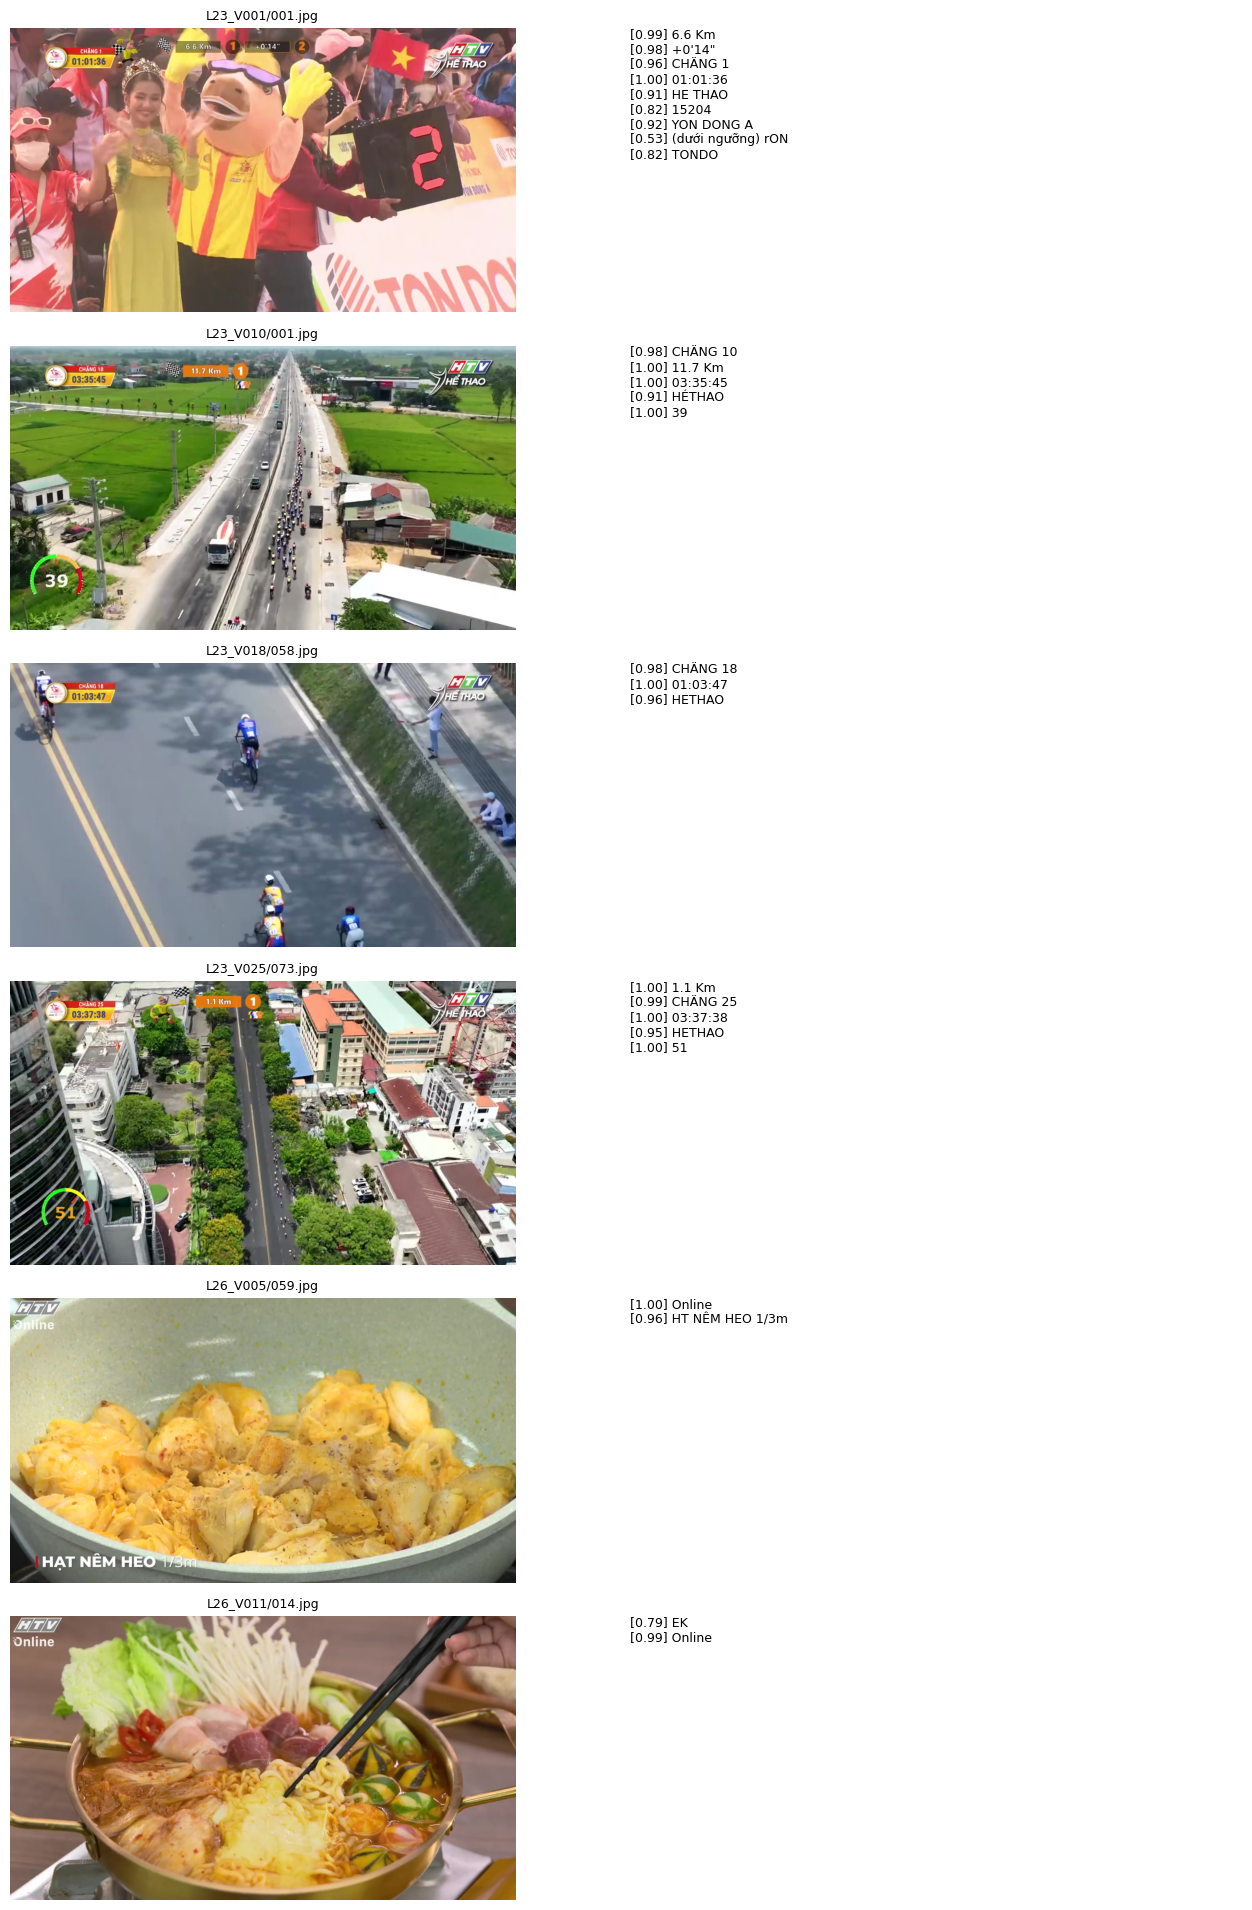

26 box đọc được, 25 đạt ngưỡng conf >= 0.6 (1 box vẫn được ghi vào JSON để chỉnh ngưỡng sau).


In [7]:
import matplotlib.pyplot as plt

# Text OCR là chữ tuỳ ý, KHÔNG phải LaTeX. Mặc định matplotlib thấy cặp '$...$' là parse
# thành công thức toán rồi nổ ValueError, làm hỏng cả cell.
plt.rcParams['text.parse_math'] = False
# DejaVu Sans Mono thiếu chữ Việt có dấu (ế, ố, ổ...); DejaVu Sans thì đủ.
plt.rcParams['font.family'] = 'DejaVu Sans'

VIZ_N = 6
_step = max(1, len(_flat) // VIZ_N)
viz_paths = _flat[::_step][:VIZ_N]

# Lấy đủ ảnh để phép đo có ý nghĩa; 6 ảnh vẽ ra chỉ là phần đầu của lô này.
timing_paths = _flat[::max(1, len(_flat) // 48)][:48]

# Lượt đầu tốn thêm thời gian khởi tạo kernel -> chạy nháp, KHÔNG tính giờ.
ocr_batch(REPLICAS[0], timing_paths[:DET_BATCH])

# Đo MỘT GPU trước để biết hai GPU có thật sự nhanh gấp đôi không. Với Paddle, hai
# predictor trong cùng process có thể cùng nằm trên gpu:0 -> "song song" chỉ là hai
# thread tranh nhau một GPU. Ngoại suy theo len(REPLICAS) lúc đó sẽ sai một nửa.
started = time.perf_counter()
for start in range(0, len(timing_paths), DET_BATCH):
    ocr_batch(REPLICAS[0], timing_paths[start:start + DET_BATCH])
ms_single = (time.perf_counter() - started) / len(timing_paths) * 1000

if len(REPLICAS) > 1:
    started = time.perf_counter()
    ocr_paths(timing_paths)
    ms_per_image = (time.perf_counter() - started) / len(timing_paths) * 1000
    speedup = ms_single / max(ms_per_image, 1e-9)
    print(f'1 GPU : {ms_single:.0f} ms/ảnh')
    print(f'{len(REPLICAS)} GPU : {ms_per_image:.0f} ms/ảnh  (nhanh gấp {speedup:.2f}x)')
    if speedup < 1.3:
        print('  !! Gần như KHÔNG tăng tốc -> hai replica đang tranh nhau một GPU.')
        print('     Dùng SHARD_COUNT = 2 với hai session Kaggle riêng (SHARD_INDEX 0 và 1)')
        print('     thay vì trông vào song song trong một process.')
else:
    ms_per_image = ms_single
    print(f'1 GPU : {ms_per_image:.0f} ms/ảnh')

viz = ocr_paths(viz_paths)

# Ngoại suy từ ms_per_image ĐO THẬT (đã tính cả song song), không nhân/chia thêm
# theo số GPU nữa — làm vậy là đếm hai lần.
hours_batch = total_images * ms_per_image / 1000 / 3600
hours_all = 177321 * ms_per_image / 1000 / 3600
print(f'\n  -> đợt này ({total_images} keyframe): {hours_batch:.1f} h')
print(f'  -> cả dataset (177.321):              {hours_all:.1f} h')
if hours_batch > 10:
    print('  !! Vượt 10h cho MỘT đợt. Đổi TIER = "small" rồi chạy lại từ cell nạp engine,')
    print('     hoặc đặt MAX_RUN_HOURS = 10.5 để vòng lặp dừng gọn và session sau chạy tiếp.')

if all(not text for text, _ in viz):
    print('\n!! Tất cả đều rỗng. Kiểm tra DET_BOX_THRESH và MIN_BOX_HEIGHT_RATIO.')

fig, axes = plt.subplots(len(viz_paths), 2, figsize=(15, 3.2 * len(viz_paths)),
                         gridspec_kw={'width_ratios': [1.6, 1]})
axes = axes.reshape(len(viz_paths), 2)
for ax_row, path, (text, boxes) in zip(axes, viz_paths, viz):
    ax_row[0].imshow(load_image(path))
    ax_row[0].set_title(f'{path.parent.name}/{path.name}', fontsize=9)
    ax_row[0].axis('off')
    if boxes:
        body = '\n'.join(
            f'[{b["conf"]:.2f}]{"" if b["conf"] >= MIN_CONFIDENCE else " (dưới ngưỡng)"} {b["text"]}'
            for b in boxes)
    else:
        body = '(không có chữ)'
    ax_row[1].text(0, 1, '\n'.join(textwrap.fill(l, 52) for l in body.split('\n'))[:900],
                   va='top', fontsize=9)
    ax_row[1].axis('off')
plt.tight_layout()
plt.show()

_all = sum(len(boxes) for _, boxes in viz)
_kept = sum(1 for _, boxes in viz for b in boxes if b['conf'] >= MIN_CONFIDENCE)
print(f'{_all} box đọc được, {_kept} đạt ngưỡng conf >= {MIN_CONFIDENCE} '
      f'({_all - _kept} box vẫn được ghi vào JSON để chỉnh ngưỡng sau).')

## 7. Ghi kết quả theo từng video

Mỗi video một file JSON, cùng schema với `Image_captioning` (thêm `ocr`, `boxes`) nên backend
dùng lại được đúng code đọc caption. Ngoài `keyframes` còn có `video_text`: hợp các dòng chữ
khác nhau trong cả video, theo thứ tự xuất hiện — dùng cho BM25 ở mức video.

**Mỗi keyframe lưu cả `boxes`** với `text` / `conf` / `bbox` của từng dòng, kể cả dòng dưới
`MIN_CONFIDENCE`. Trường `ocr` chỉ là phần đạt ngưỡng, ghép sẵn cho tiện. Đổi ngưỡng sau này
chỉ cần chạy mục 9 — **không phải chạy lại GPU**.

Ghi `.partial.json` sau mỗi chunk nên mất session cũng chỉ mất vài chục ảnh cuối.

In [8]:
import json
import shutil

RESULT_GLOB = 'L[0-9][0-9]_V[0-9][0-9][0-9].json'
WORK_CHUNK = DET_BATCH * max(1, len(REPLICAS))   # đủ việc cho mọi GPU mỗi vòng
VIDEO_TEXT_LIMIT = 20000                         # chặn trần cho video toàn chữ chạy chữ

def output_json_path(video_id):
    return OUTPUT_ROOT / f'{video_id}.json'

def partial_path(video_id):
    return CHECKPOINT_DIR / f'{video_id}.partial.json'

def atomic_write(path, payload):
    temp = path.with_suffix(path.suffix + '.tmp')
    temp.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding='utf-8')
    temp.replace(path)

def is_done(video_id):
    path = output_json_path(video_id)
    if not path.is_file():
        return False
    try:
        payload = json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return False
    return payload.get('run_id') == RUN_ID and bool(payload.get('complete'))

def restore_previous_results():
    """/kaggle/working bị xoá khi session kết thúc, nên đợt sau notebook sẽ OCR lại từ đầu.
    Save Version -> đợt sau Add Input -> Your Work -> Notebook Output, cell này chép ngược về."""
    if not IS_KAGGLE or not Path('/kaggle/input').is_dir():
        return 0
    copied = 0
    for pattern in ('*', '*/*', '*/*/*'):
        for candidate in sorted(Path('/kaggle/input').glob(pattern)):
            # Bỏ nhánh dataset keyframe: hàng trăm nghìn ảnh, quét vào chỉ tốn thời gian.
            if not candidate.is_dir() or candidate == dataset_root or dataset_root in candidate.parents:
                continue
            if candidate.resolve() == OUTPUT_ROOT:
                continue
            for source in sorted(candidate.glob(RESULT_GLOB)):
                target = OUTPUT_ROOT / source.name
                # Bản đang ở output có thể mới hơn -> chỉ ghi đè khi bản cũ dài hơn.
                if target.exists() and target.stat().st_size >= source.stat().st_size:
                    continue
                shutil.copy2(source, target)
                copied += 1
    return copied

def output_tag():
    """Nhãn cho file zip, để nhiều đợt chạy khác nhau không đè lên nhau ở panel Output."""
    if TARGET_FOLDERS:
        # Sắp xếp trước khi rút gọn: nhóm ['L26_a',...,'L27','L23'] mà lấy phần tử đầu/cuối
        # nguyên trạng sẽ ra 'L26_atoiL23', đọc như một khoảng ngược.
        names = sorted(f.replace('Keyframes_', '') for f in TARGET_FOLDERS)
        tag = '-'.join(names) if len(names) <= 4 else f'{names[0]}toi{names[-1]}'
    else:
        tag = 'all'
    return tag + (f'_shard{SHARD_INDEX}of{SHARD_COUNT}' if SHARD_COUNT > 1 else '')

def pack_outputs():
    """Nén MỌI file JSON đang có trong OUTPUT_ROOT (kể cả bản khôi phục từ đợt trước)."""
    if not IS_KAGGLE:
        return
    files = list(OUTPUT_ROOT.glob(RESULT_GLOB))
    if not files:
        print('Chưa có file JSON nào để nén.')
        return
    archive = shutil.make_archive(f'/kaggle/working/ocr_v6_{output_tag()}', 'zip', OUTPUT_ROOT)
    print(f'Đã nén {len(files)} video -> {archive} '
          f'({Path(archive).stat().st_size / 1024 ** 2:.1f} MB). Tải ở panel Output bên phải.')

def build_video_text(keyframes):
    """Hợp các dòng chữ KHÁC NHAU trong cả video, giữ thứ tự xuất hiện lần đầu."""
    seen, ordered = set(), []
    for item in keyframes:
        for line in (item['ocr'] or '').split('\n'):
            line = line.strip()
            key = line.casefold()
            if line and key not in seen:
                seen.add(key)
                ordered.append(line)
    return '\n'.join(ordered)[:VIDEO_TEXT_LIMIT]

def ocr_video(video_dir, progress_every=200):
    video_id = video_dir.name
    mapping = load_keyframe_map(video_id)
    images = list_images(video_dir)

    payload = None
    if partial_path(video_id).is_file():
        try:
            saved = json.loads(partial_path(video_id).read_text(encoding='utf-8'))
            if saved.get('run_id') == RUN_ID:
                payload = saved
        except Exception:
            payload = None
    if payload is None:
        payload = {'video_id': video_id, 'source': str(video_dir), 'model': MODEL_ID,
                   'run_id': RUN_ID, 'tier': TIER, 'language': 'vi',
                   'min_confidence': MIN_CONFIDENCE,
                   'min_box_height_ratio': MIN_BOX_HEIGHT_RATIO,
                   'det_unclip_ratio': DET_UNCLIP_RATIO,
                   'dedup_max_distance': DEDUP_MAX_DISTANCE, 'dedup_hash_size': DEDUP_HASH_SIZE,
                   'has_keyframe_map': mapping is not None, 'complete': False,
                   'keyframe_count': 0, 'ocr_count': 0, 'with_text_count': 0,
                   'box_count': 0, 'video_text': '', 'keyframes': []}

    done = {item['keyframe'] for item in payload['keyframes']}
    pending = [p for p in images if p.name not in done]
    groups = group_duplicates(pending)
    if pending and len(groups) < len(pending):
        print(f'    {len(pending)} keyframe -> {len(groups)} ảnh cần model '
              f'({100 * (1 - len(groups) / len(pending)):.0f}% trùng)')

    def record(image_path, text, boxes, duplicate_of):
        order = keyframe_order(image_path)
        mapped = mapping.get(order) if mapping and order is not None else None
        payload['keyframes'].append({
            'keyframe': image_path.name, 'n': order,
            'frame_idx': mapped['frame_idx'] if mapped else None,
            'pts_time': mapped['pts_time'] if mapped else None,
            'fps': mapped['fps'] if mapped else None,
            'ocr': text,
            # GIỮ CẢ box dưới ngưỡng conf: đổi MIN_CONFIDENCE sau này chỉ cần chạy mục 9,
            # không phải chạy lại GPU trên 177k ảnh.
            'boxes': boxes,
            'duplicate_of': duplicate_of,
        })

    for start in range(0, len(groups), WORK_CHUNK):
        chunk = groups[start:start + WORK_CHUNK]
        results = ocr_paths([representative for representative, _ in chunk])
        for (representative, duplicates), (text, boxes) in zip(chunk, results):
            record(representative, text, boxes, None)
            for duplicate in duplicates:
                record(duplicate, text, boxes, representative.name)   # ảnh trùng chép lại text
        payload['keyframe_count'] = len(payload['keyframes'])
        payload['ocr_count'] = sum(k['duplicate_of'] is None for k in payload['keyframes'])
        atomic_write(partial_path(video_id), payload)
        processed = min(start + WORK_CHUNK, len(groups))
        if progress_every and processed % progress_every < WORK_CHUNK:
            print(f'    {processed}/{len(groups)} ảnh')

    payload['keyframes'].sort(key=lambda k: (k['n'] is None, k['n'] or 0, k['keyframe']))
    payload['with_text_count'] = sum(bool(k['ocr']) for k in payload['keyframes'])
    payload['box_count'] = sum(len(k['boxes']) for k in payload['keyframes'])
    payload['video_text'] = build_video_text(payload['keyframes'])
    payload['complete'] = True
    atomic_write(output_json_path(video_id), payload)
    if partial_path(video_id).exists():
        partial_path(video_id).unlink()
    return payload

## 8. Chạy toàn bộ

In [ ]:
import traceback

restored = restore_previous_results()
if restored:
    print(f'Nạp lại {restored} file JSON từ các đợt trước.')

pending_videos = [v for v in video_dirs if not is_done(v.name)]
print(f'{len(video_dirs)} video trong shard: đã xong {len(video_dirs) - len(pending_videos)}, '
      f'còn {len(pending_videos)}\n')

success = failed = 0
failures = []
started_all = time.time()
frames_done = 0
pending_frames = [IMAGE_COUNTS[v] for v in pending_videos]   # đã đếm ở cell liệt kê
frames_left = sum(pending_frames)
# Dừng giữa HAI video chứ không để Kaggle chém giữa chừng, để còn kịp đóng gói.
deadline = started_all + MAX_RUN_HOURS * 3600 if MAX_RUN_HOURS else None

for index, video_dir in enumerate(pending_videos, 1):
    if deadline and time.time() > deadline:
        print(f'\nĐã chạy đủ {MAX_RUN_HOURS}h -> dừng, còn {len(pending_videos) - index + 1} video.')
        break
    print(f'[{index}/{len(pending_videos)}] {video_dir.name}')
    started = time.time()
    try:
        payload = ocr_video(video_dir)
        frames_done += payload['keyframe_count']
        frames_left -= pending_frames[index - 1]
        elapsed = time.time() - started_all
        eta = frames_left / max(frames_done / max(elapsed, 1e-9), 1e-9) / 3600
        print(f"    {payload['keyframe_count']} keyframe | {payload['ocr_count']} lượt gọi model "
              f"| {payload['with_text_count']} có chữ | {payload['box_count']} box "
              f"| {time.time() - started:.0f}s | ETA còn {eta:.1f}h")
        success += 1
    except Exception as exc:
        failed += 1
        failures.append({'video_id': video_dir.name, 'error': repr(exc)})
        traceback.print_exc()

if failures:
    atomic_write(OUTPUT_ROOT / '_failed.json', failures)

remaining_videos = [v for v in video_dirs if not is_done(v.name)]
print(f'\nXong sau {(time.time() - started_all) / 60:.1f} phút: success={success}, failed={failed}')
print(f'Shard này: {len(video_dirs) - len(remaining_videos)}/{len(video_dirs)} video đã có OCR.')
if remaining_videos:
    print(f'CÒN {len(remaining_videos)} video. Save Version, rồi mở session mới và '
          'Add Input -> Your Work -> Notebook Output để không OCR lại từ đầu.')
else:
    print('XONG TOÀN BỘ SHARD.')
pack_outputs()

539 video trong shard: đã xong 0, còn 539

[1/539] L23_V001
    50 keyframe | 50 lượt gọi model | 50 có chữ | 393 box | 19s | ETA còn 9.1h
[2/539] L23_V002
    93 keyframe | 93 lượt gọi model | 93 có chữ | 395 box | 30s | ETA còn 8.3h
[3/539] L23_V003
    69 keyframe | 69 lượt gọi model | 69 có chữ | 404 box | 25s | ETA còn 8.4h
[4/539] L23_V004
    109 keyframe | 109 lượt gọi model | 109 có chữ | 873 box | 44s | ETA còn 8.8h
[5/539] L23_V005


## 9. Kiểm tra chất lượng

Bốn con số cần nhìn:

- **% keyframe có chữ** — bản tin truyền hình, kỳ vọng khá cao (thường >50%). Gần 0% nghĩa là
  detection hỏng, đừng dùng kết quả.
- **Phân bố confidence** — nếu phần lớn box nằm dưới `MIN_CONFIDENCE` thì ngưỡng quá chặt và
  bạn đang vứt đi text thật. Chỉnh ở mục 10, **không cần chạy lại GPU**.
- **Số box trung bình mỗi frame** — quá cao (>25) thường nghĩa là `DET_BOX_THRESH` quá thấp
  nên detector bắt cả hoa văn nền thành chữ.
- **Tỉ lệ ký tự có dấu** — với tiếng Việt thật, kỳ vọng >15% ký tự chữ cái là có dấu. Thấp hơn
  nhiều nghĩa là model đang **nuốt dấu** → xem lại `DET_UNCLIP_RATIO`.

In [ ]:
from collections import Counter

files = sorted(OUTPUT_ROOT.glob(RESULT_GLOB))
frames = text_frames = model_calls = boxes_total = 0
letters = accented = 0
conf_histogram = Counter()
no_map = []
samples = []

for path in files:
    payload = json.loads(path.read_text(encoding='utf-8'))
    frames += payload['keyframe_count']
    text_frames += payload.get('with_text_count', 0)
    model_calls += payload.get('ocr_count', 0)
    if not payload.get('has_keyframe_map'):
        no_map.append(payload['video_id'])
    for item in payload['keyframes']:
        if item.get('duplicate_of') is not None:
            continue          # ảnh trùng chép lại text, đếm vào sẽ thổi phồng thống kê
        for box in item.get('boxes', []):
            boxes_total += 1
            conf_histogram[min(9, int(box['conf'] * 10))] += 1
            for character in box['text']:
                if character.isalpha():
                    letters += 1
                    # NFD tách 'ế' thành 'e' + 2 dấu -> dài hơn 1 ký tự nghĩa là CÓ dấu.
                    if len(unicodedata.normalize('NFD', character)) > 1:
                        accented += 1
        if item['ocr'] and len(samples) < 15:
            samples.append(f"{payload['video_id']} n={item['n']} frame={item['frame_idx']}: "
                           + item['ocr'].replace('\n', ' / ')[:110])

print(f'{len(files)} video | {frames} keyframe')
if frames:
    print(f'  có chữ      : {text_frames} ({100 * text_frames / frames:.1f}%)')
    print(f'  gọi model   : {model_calls} ({100 * model_calls / frames:.1f}% — phần còn lại là ảnh trùng)')
    print(f'  box/frame   : {boxes_total / max(model_calls, 1):.1f} trung bình')
print(f'  thiếu map   : {len(no_map)} video' + (f' {no_map[:10]}' if no_map else ''))

if letters:
    ratio = 100 * accented / letters
    verdict = 'ổn' if ratio >= 15 else 'THẤP BẤT THƯỜNG -> model có thể đang nuốt dấu'
    print(f'  ký tự có dấu: {accented}/{letters} ({ratio:.1f}%) -> {verdict}')

if boxes_total:
    print(f'\nPhân bố confidence ({boxes_total} box, ngưỡng hiện tại {MIN_CONFIDENCE}):')
    for bucket in range(10):
        count = conf_histogram.get(bucket, 0)
        marker = ' <- dưới ngưỡng' if (bucket + 1) / 10 <= MIN_CONFIDENCE else ''
        print(f'  {bucket / 10:.1f}-{(bucket + 1) / 10:.1f} {count:>8} '
              f'{"#" * int(40 * count / boxes_total)}{marker}')
    below = sum(c for b, c in conf_histogram.items() if (b + 1) / 10 <= MIN_CONFIDENCE)
    print(f'  -> {100 * below / boxes_total:.1f}% số box đang bị ngưỡng loại khỏi trường "ocr" '
          '(vẫn còn nguyên trong "boxes").')

print('\nMẫu chữ đọc được:')
for line in samples:
    print(' ', line)

## 10. Chỉnh lại ngưỡng confidence — **không cần chạy lại GPU**

Đây là lý do mọi box đều được lưu kèm `conf`. Sau khi nhìn biểu đồ ở mục 9, nếu thấy ngưỡng
quá chặt (vứt mất text thật) hoặc quá lỏng (lọt nhiều rác), sửa `NEW_CONFIDENCE` rồi chạy ô
này — nó dựng lại `ocr` và `video_text` từ `boxes` đã có sẵn trên đĩa.

Chạy trên CPU, vài giây cho cả nghìn video. Đặt `DRY_RUN = True` để xem trước khi ghi.

In [ ]:
NEW_CONFIDENCE = MIN_CONFIDENCE   # đổi số này rồi chạy lại ô
DRY_RUN = True                    # True = chỉ xem, không ghi đè file

changed = 0
delta_lines = 0
for path in sorted(OUTPUT_ROOT.glob(RESULT_GLOB)):
    payload = json.loads(path.read_text(encoding='utf-8'))
    touched = False
    for item in payload['keyframes']:
        rebuilt = compose_text(item.get('boxes', []), NEW_CONFIDENCE)
        if rebuilt != item['ocr']:
            delta_lines += len(rebuilt.split('\n')) - len(item['ocr'].split('\n'))
            item['ocr'] = rebuilt
            touched = True
    if touched:
        changed += 1
        payload['min_confidence'] = NEW_CONFIDENCE
        payload['with_text_count'] = sum(bool(k['ocr']) for k in payload['keyframes'])
        payload['video_text'] = build_video_text(payload['keyframes'])
        if not DRY_RUN:
            atomic_write(path, payload)

verb = 'sẽ đổi' if DRY_RUN else 'đã đổi'
print(f'Ngưỡng {MIN_CONFIDENCE} -> {NEW_CONFIDENCE}: {verb} {changed} video, '
      f'{delta_lines:+d} dòng chữ.')
if DRY_RUN and changed:
    print('Đặt DRY_RUN = False rồi chạy lại để ghi thật.')

## 11. Đóng gói để tải về

Cell chạy chính đã tự gọi `pack_outputs()` khi kết thúc bình thường. **Chạy lại ô này** nếu
session bị cắt giữa chừng nên chưa kịp nén, hoặc bạn vừa chỉnh ngưỡng confidence ở mục 10.

Zip lấy tên theo nhóm folder đang chạy nên các đợt khác nhau không đè lên nhau, và nó nén
**toàn bộ** JSON đang có trong thư mục output — zip mới nhất luôn là bản đầy đủ nhất.

Tải về rồi giải nén thẳng vào `Feature_Dataset/OCR/` trong repo — các file `<VIDEO_ID>.json`
nằm phẳng ở gốc zip, mỗi video một file nên các đợt khác nhau không đụng nhau.

In [ ]:
pack_outputs()